# Phân Tích Dữ Liệu Chất Lượng Không Khí (Bụi mịn & Khí thải)
Pipeline tuân thủ chặt chẽ các bước tiền xử lý: Làm sạch, Chuẩn hóa, Giảm chiều dữ liệu và Mô hình hóa.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Thu thập dữ liệu

In [36]:
data_path = r'../data/Aotizhongxin_Raw.csv'
print(f"Đang đọc dữ liệu từ: {data_path}")
df = pd.read_csv(data_path, sep=',', decimal='.')

# Chuẩn hóa thời gian và tên cột
df['Datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('Datetime', inplace=True)
df.rename(columns={
    'station': 'city', 'PM2.5': 'pm25', 'PM10': 'pm10',
    'SO2': 'so2', 'NO2': 'no2', 'CO': 'co', 'O3': 'o3'
}, inplace=True)

# Lọc giữ các cột mục tiêu
columns_to_keep = ['city', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
df = df[[col for col in columns_to_keep if col in df.columns]]

Đang đọc dữ liệu từ: ../data/Aotizhongxin_Raw.csv


## 2. Làm sạch dữ liệu

In [37]:
print("\nSố lượng giá trị thiếu ban đầu:\n", df.isnull().sum())

# --- XỬ LÝ GIÁ TRỊ THIẾU ---
# 1. Biến phân loại (Categorical): Nhóm giá trị thiếu vào "Missing"
if 'city' in df.columns:
    df['city'] = df['city'].fillna('Missing')

# 2. Biến định lượng (Numeric): Ước tính giá trị còn thiếu bằng Nội suy (Interpolation)
df.interpolate(method='time', inplace=True)

# 3. Thay thế giá trị thiếu còn sót lại bằng giá trị trung vị (Median)
df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing values sau xử lý:", df.isnull().sum().sum())

# --- XỬ LÝ NGOẠI LAI (OUTLIERS) ---
# Cách 1: Sử dụng phương pháp Mean +/- 3*Std
def detect_outliers_zscore(data, column):
    mean_val = data[column].mean()
    std_val = data[column].std()
    lower_bound = mean_val - 3 * std_val
    upper_bound = mean_val + 3 * std_val
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

outliers_z = detect_outliers_zscore(df, 'pm25')
print(f"\nSố dòng ngoại lai PM2.5 (PP X ± 3s): {len(outliers_z)} dòng")

# Cách 2: Sử dụng phương pháp Khoảng tứ phân vị IQR (Biểu đồ hộp)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

outliers_iqr = detect_outliers_iqr(df, 'pm25')
print(f"Số dòng ngoại lai PM2.5 (PP IQR): {len(outliers_iqr)} dòng")

# Lưu kết quả
processed_data_path = r'../data/processed_data.csv'
df.to_csv(processed_data_path)


Số lượng giá trị thiếu ban đầu:
 city       0
pm25     925
pm10     718
o3      1719
no2     1023
so2      935
co      1776
dtype: int64

Missing values sau xử lý: 0

Số dòng ngoại lai PM2.5 (PP X ± 3s): 615 dòng
Số dòng ngoại lai PM2.5 (PP IQR): 1653 dòng


## 3. Co giãn và chuẩn hoá dữ liệu

In [38]:
features = ['pm10', 'o3', 'no2', 'so2', 'co']
target = 'pm25'

# Chuẩn hoá dữ liệu (Standardization Z-score) để đưa các đặc trưng về cùng thang tỷ lệ
# Giúp giải quyết vấn đề thuộc tính tiền lương/độ lớn chi phối kết quả
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

df_scaled = pd.DataFrame(X_scaled, columns=features, index=df.index)
print("\nDữ liệu sau khi chuẩn hoá (Z-score):")
display(df_scaled.head())


Dữ liệu sau khi chuẩn hoá (Z-score):


,pm10,o3,no2,so2,co
Datetime,,,,,
2013-03-01 00:00:00,-1.114935,0.378033,-1.407393,-0.592867,-0.778358
2013-03-01 01:00:00,-1.072945,0.378033,-1.407393,-0.592867,-0.778358
2013-03-01 02:00:00,-1.083443,0.308258,-1.326313,-0.548818,-0.778358
2013-03-01 03:00:00,-1.093940,0.290814,-1.299286,-0.284524,-0.778358
2013-03-01 04:00:00,-1.125433,0.290814,-1.272260,-0.240475,-0.778358


## 4. Giảm chiều và biến đổi dữ liệu (PCA)


Tỷ lệ phương sai giữ lại của 2 thành phần chính: 76.98%


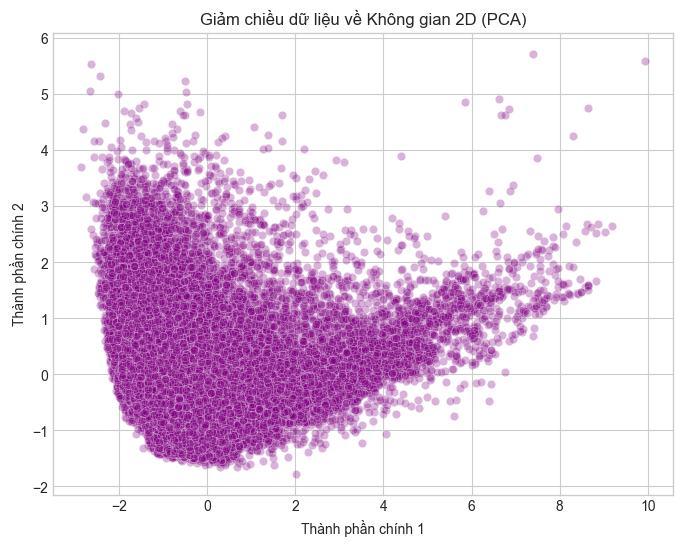

In [39]:
# Sử dụng phương pháp Phân tích thành phần chính (PCA) để biểu diễn dữ liệu gọn hơn
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df.index)

variance = pca.explained_variance_ratio_.sum() * 100
print(f"\nTỷ lệ phương sai giữ lại của 2 thành phần chính: {variance:.2f}%")

# Trực quan PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.3, color='purple')
plt.title('Giảm chiều dữ liệu về Không gian 2D (PCA)')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.show()

## 5. Trực quan hóa dữ liệu

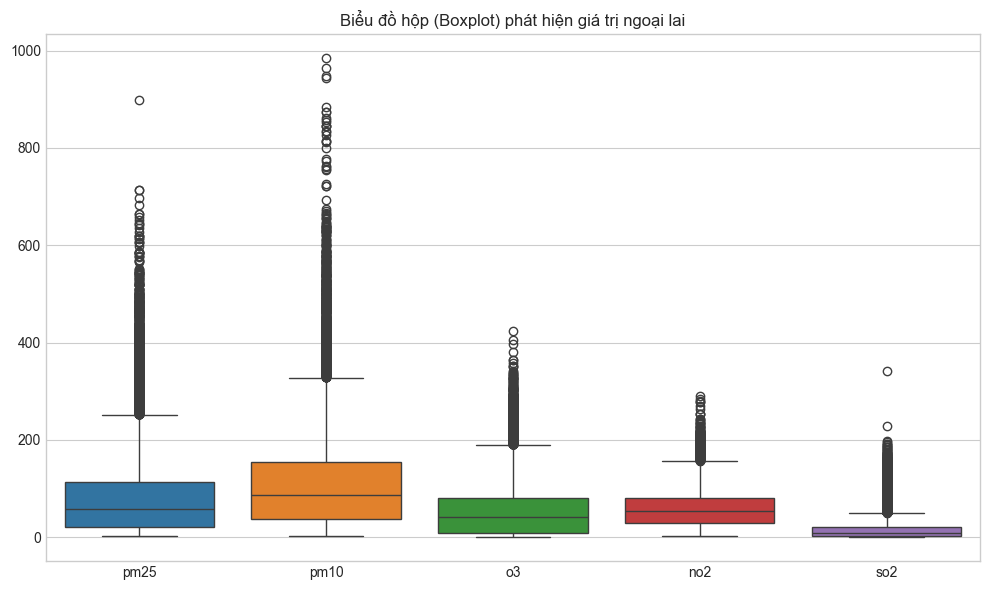

In [40]:
# Boxplot phát hiện ngoại lai trực quan
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['pm25', 'pm10', 'o3', 'no2', 'so2']])
plt.title('Biểu đồ hộp (Boxplot) phát hiện giá trị ngoại lai')
plt.tight_layout()
plt.show()

## 6. Xây dựng Mô Hình Hồi Quy

In [41]:
y = df[target]
# Truyền dữ liệu đã CHUẨN HÓA vào mô hình
X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("\nKết quả Linear Regression:")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2:  {r2_score(y_test, y_pred):.4f}")


Kết quả Linear Regression:
MSE: 1055.5460
MAE: 21.4094
R2:  0.8341
